In [13]:
import torch
import json
import cv2
import os
import einops as eps
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from dataset.InterHand26M.utils.mano import mano

In [14]:
fh_root = "./data/freihand/"

In [48]:
ix = 3004

img_path = os.path.join(fh_root, "training", "rgb", f"{ix:08d}.jpg")
img = cv2.imread(img_path)
img = img[:,:,::-1].copy()

# seg_path = os.path.join(fh_root, "evaluation", "segmap", f"{ix:08d}.png")
# seg_img = cv2.imread(seg_path)
# img = img * (seg_img != 0).astype(int)
seg_path = os.path.join(fh_root, "training", "mask", f"{ix:08d}.jpg")
seg_img = cv2.imread(seg_path)
img = img * (seg_img > 200).astype(int)

In [40]:
with open(os.path.join(fh_root, "evaluation_K.json"), "r") as f:
    training_K = json.load(f)
with open(os.path.join(fh_root, "training_xyz.json"), "r") as f:
    training_xyz = json.load(f)
with open(os.path.join(fh_root, "training_mano.json"), "r") as f:
    training_mano = json.load(f)

training_K = np.array(training_K)
training_xyz = np.array(training_xyz)
training_mano = np.array(training_mano, dtype=np.float32)

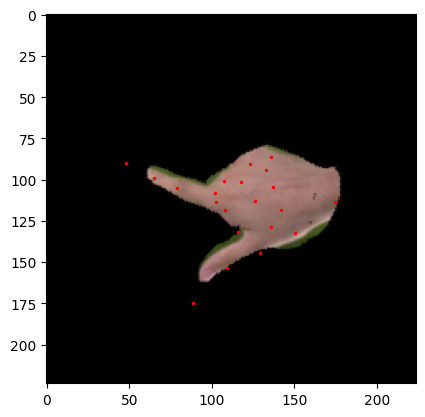

In [49]:
import kornia

kps3d = training_xyz[ix]
intr = training_K[ix]
mano_data = training_mano[ix]

rot_deg = torch.tensor([torch.pi / 4])  # torch.rand(size=(1,)) * torch.pi * 2
rot_ang = rot_deg * 180 / torch.pi

rot_mat = torch.Tensor([
    [torch.cos(-rot_deg), -torch.sin(-rot_deg), 0],
    [torch.sin(-rot_deg), torch.cos(-rot_deg), 0],
    [0, 0, 1]
])
kps3d = (rot_mat @ kps3d.T).T
kps2d = intr.dot(kps3d.T).T
kps2d = kps2d[..., :-1] / kps2d[..., -1:]

img_tensor = torch.from_numpy(img.copy()).permute(2,0,1)[None,...] / 255.
img_tensor = kornia.geometry.transform.rotate(img_tensor, rot_ang)[0]

plt.imshow(img_tensor.permute(1,2,0))
plt.scatter(kps2d[:,0], kps2d[:,1], c='r', s=2)

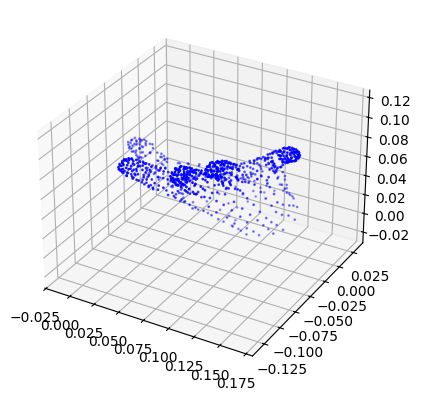

In [7]:
%matplotlib inline

pose, shape, uv_root, scale = eps.unpack(mano_data, [(48,), (10,), (2,), (1,)], "d *")
r_output = mano.layer['right'](betas=torch.from_numpy(shape),
                               hand_pose=torch.from_numpy(pose[:,3:]),
                               global_orient=torch.from_numpy(pose[:,:3]),
                               transl=torch.zeros(1, 3))

v3d = r_output.vertices[0].numpy()

fig3d = plt.figure(3)
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.scatter(v3d[:,0], v3d[:,1], v3d[:,2], c='b', s=1)

plt.show()

In [73]:
import kornia

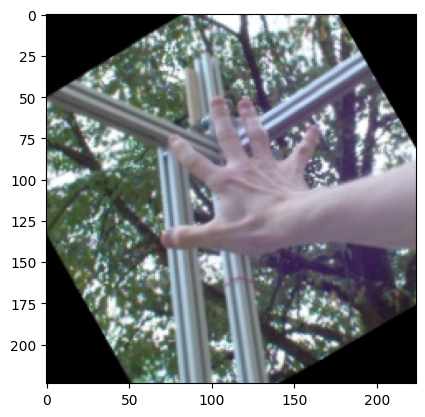

In [8]:
img_tensor = torch.from_numpy(img.copy()) / 255.
rotated_img_tensor = kornia.geometry.transform.rotate(eps.rearrange(img_tensor, "h w c -> c h w")[None,...], torch.Tensor([30.]))
rotated_img_tensor = eps.rearrange(rotated_img_tensor[0], 'c h w -> h w c')
plt.imshow(rotated_img_tensor)

# dataset

In [4]:
import torch
from dataset import FreiHand
import matplotlib.pyplot as plt
from dataset.InterHand26M.utils.mano import mano

In [7]:
fh_dataset = FreiHand(mode="train")

In [15]:
len(fh_dataset)

32560

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.940697e-08..0.9325598].


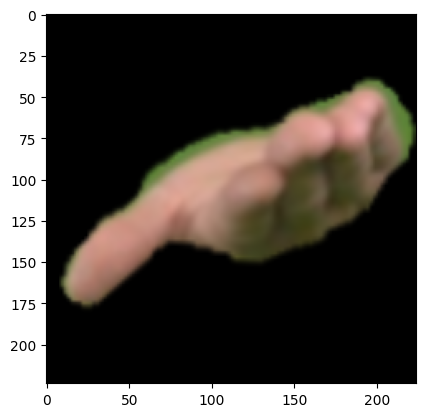

In [10]:
def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:,None,None] + mean[:,None,None]
    return img.permute(1,2,0)

item = fh_dataset[302]

intr = item["K"]
kps3d = item["joints_3d"]

kps2d = (intr @ kps3d.T).T
kps2d = kps2d[..., :-1] / kps2d[..., -1:]

plt.imshow(unnormalize(item['image']))
# plt.scatter(kps2d[:,0], kps2d[:,1], c='r', s=2)

In [14]:
item['joints_3d']

tensor([[ 0.0331, -0.0129,  0.8022],
        [-0.0031, -0.0118,  0.7769],
        [-0.0278,  0.0050,  0.7593],
        [-0.0431,  0.0166,  0.7380],
        [-0.0657,  0.0412,  0.7248],
        [ 0.0028,  0.0056,  0.7106],
        [ 0.0046,  0.0009,  0.6775],
        [ 0.0068, -0.0079,  0.6553],
        [ 0.0117, -0.0141,  0.6293],
        [ 0.0263, -0.0023,  0.7005],
        [ 0.0265, -0.0096,  0.6683],
        [ 0.0269, -0.0192,  0.6456],
        [ 0.0313, -0.0238,  0.6185],
        [ 0.0488, -0.0154,  0.7090],
        [ 0.0457, -0.0192,  0.6788],
        [ 0.0459, -0.0269,  0.6541],
        [ 0.0452, -0.0320,  0.6272],
        [ 0.0620, -0.0292,  0.7184],
        [ 0.0598, -0.0328,  0.6978],
        [ 0.0553, -0.0373,  0.6793],
        [ 0.0512, -0.0375,  0.6577]])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1179044..2.2489085].


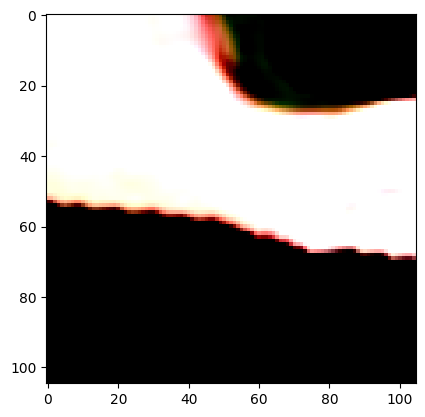

In [14]:
import torch
import kornia

def crop_img(img: torch.Tensor, bbox_center, bbox_size, squarify=True, avoid_zero=False):
    '''
    center, size 均遵从 interwild 工作中的定义，是一个二元组。第一、二个元素分别
    是水平方向和垂直方向的位置和长度。
    '''
    assert isinstance(img, torch.Tensor), "Only torch.Tensor image is supported"
    
    w_center, h_center = bbox_center
    width, height = bbox_size

    if squarify:
        length = max(width, height)
        width = length
        height = length
    if avoid_zero:
        width = max(width, 2)  # ! use 2 instead of 1
        height = max(height, 2)
    
    w_min = (w_center - width / 2)
    h_min = (h_center - height / 2)
    w_max = (w_center + width / 2)
    h_max = (h_center + height / 2)
    boxes = torch.tensor([[
        [w_min, h_min], [w_max, h_min], [w_max, h_max], [w_min, h_max]
    ]])
    output_size = (int(height), int(width))

    cropped_img = kornia.geometry.transform.crop_and_resize(img[None,...], boxes, output_size)
    return cropped_img[0]
    

y_min, y_max = float(kps2d[:,0].min()), float(kps2d[:,0].max())
x_min, x_max = float(kps2d[:,1].min()), float(kps2d[:,1].max())
bbox_center = ((x_min + x_max) / 2, (y_min + y_max) / 2)
bbox_size = ((x_max - x_min) * 1.2, (y_max - y_min) * 1.2)

img_crop = crop_img(item['image'], bbox_center, bbox_size)
plt.imshow(img_crop.permute(1,2,0))

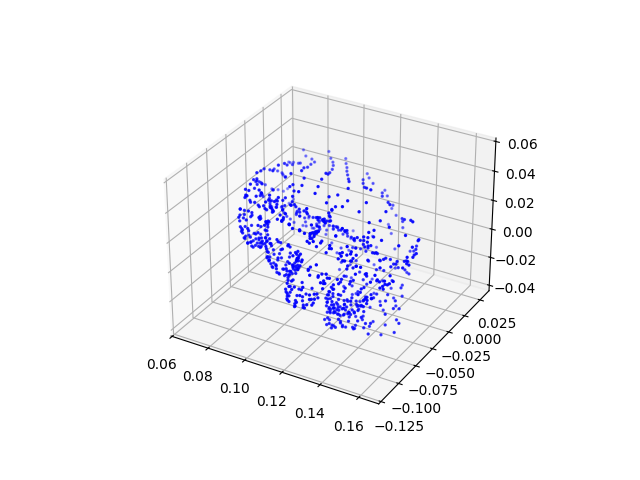

In [16]:
%matplotlib widget

import torch

shape = item["shape"]
pose = item["pose"]

r_output = mano.layer['right'](betas=shape[None,:],
                               hand_pose=pose[None,3:],
                               global_orient=pose[None,:3],
                               transl=torch.zeros(1, 3))

v3d = r_output.vertices[0].numpy()

fig3d = plt.figure(3)
ax3d = fig3d.add_subplot(111, projection='3d')
ax3d.scatter(v3d[:,0], v3d[:,1], v3d[:,2], c='b', s=2)

plt.show()